# Phase 2 Data Analytics, Visualization

## 1. Introduction

This report presents Phase II of the CO₂ Emissions from Cars project for the SECP3223 Data Analytics Programming course. Building upon the data cleaning, preparation, and aggregation completed in Phase I, this phase focuses on performing data analytics, applying machine learning classification and clustering techniques, and visualising the results. The aim is to gain deeper insights into vehicle emission patterns in Malaysia and provide meaningful recommendations for reducing CO₂ emissions in the transportation sector.

## 2. Summary Analytics based on Phase 1

**Research Question 1: How do fuel types and vehicle characteristics affect CO₂ emissions?**

The analysis shows that diesel vehicles have a significantly higher average CO₂ emission of approximately 262 g/km, compared to petrol vehicles, which have an average emission of around 184 g/km. Despite diesel cars emitting more CO₂ per vehicle, petrol vehicles dominate the total registrations, with 7637 petrol vehicles compared to 1575 diesel vehicles in the dataset.

Additionally, the average fuel consumption combined for diesel vehicles is 11.38 L/100km, which is higher than petrol vehicles at 7.99 L/100km. This indicates that diesel vehicles consume more fuel and produce more emissions per kilometre driven. These findings highlight the importance of promoting cleaner fuel types and improving fuel efficiency to reduce overall transportation CO₂ emissions in Malaysia.

**Research Question 2: Which vehicle categories contribute the most to carbon output in Malaysia based on 2025 car registration data?**

Standard SUVs have the highest average CO₂ emissions (294 g/km), followed by subcompact cars (282 g/km). However, compact cars and small SUVs, despite having lower per-vehicle emissions, contribute greatly to total emissions due to their large registration counts (4217 and 3298 vehicles respectively).

This shows that both high-emission vehicle types and high-population categories significantly impact Malaysia’s total transport emissions.

**Research Question 3: How do engine size and cylinder count relate to emissions?**

The top CO₂ emitters are mainly luxury and high-performance cars. The Bentley Mulsanne has the highest emission at 437 g/km, followed by the Audi R8 (409 g/km) and Aston Martin Vanquish (359 g/km). Most of these cars have large engines and high cylinder counts, which directly increase fuel consumption and CO₂ emissions.

This confirms that larger engine sizes and more cylinders lead to higher emissions, highlighting the need to regulate high-performance vehicles to reduce overall CO₂ output.

**Research Question 4: Which states register the most high-emission cars?**

Kuala Lumpur has the highest average CO₂ emissions (208 g/km), with a maximum of 437 g/km, indicating many high-emission vehicles. Selangor and Johor also register large numbers of high-emission cars due to their high urban populations. These states are key contributors to Malaysia’s transport emissions and should be prioritised for targeted low-emission vehicle policies.

**Research Question 5: What is the relationship between fuel consumption and emissions?**

The analysis shows that fuel consumption is strongly related to CO₂ emissions. Both diesel and petrol vehicles have similar fuel efficiency values (around 23.01 L/100km), and higher fuel consumption generally results in higher CO₂ emissions. This confirms that improving fuel efficiency directly contributes to reducing emissions, supporting the importance of promoting low-consumption and fuel-efficient vehicle technologies to reduce environmental impact.

## 3. Machine Learning Analysis

### 3.1 Clustering: Group Cars by Machanical and Emission Features

In addition to classification, K-Means clustering was applied to identify natural groupings among In this analysis, K-Means clustering was applied to group car models based on their average CO₂ emissions, engine size, and cylinder count. The aim was to identify natural groupings among car models to understand emission patterns and support targeted environmental policies.

The dataset was grouped by car model to calculate mean values for CO₂ emissions, engine size, and cylinders. Features were then scaled using StandardScaler to ensure equal contribution to clustering, and K-Means was performed with three clusters to categorise car models into low, medium, and high emission groups.

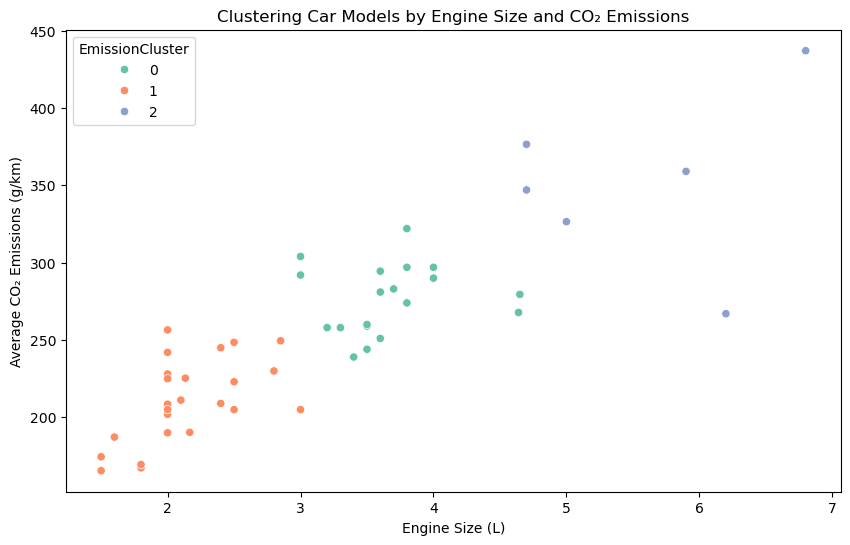

                co2emissions                                                 \
                       count        mean        std    min      25%     50%   
EmissionCluster                                                               
0                       19.0  276.357895  22.288894  239.0  258.500  279.50   
1                       24.0  210.954861  27.134227  165.5  190.250  208.75   
2                        6.0  352.166667  56.168200  267.0  331.625  353.00   

                                enginesize            ...               \
                     75%    max      count      mean  ...    75%   max   
EmissionCluster                                       ...                
0                293.250  322.0       19.0  3.662632  ...  3.800  4.65   
1                228.500  256.5       24.0  2.147917  ...  2.425  3.00   
2                372.125  437.0        6.0  5.550000  ...  6.125  6.80   

                cylinders                                                     
 

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

# Then import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('merged_data.csv')

# Group by car model to calculate average emissions and mechanical specs
model_group = df.groupby('model').agg({
    'co2emissions': 'mean',
    'enginesize': 'mean',
    'cylinders': 'mean'
}).reset_index()

# Define numeric columns for clustering
numeric_cols = ['co2emissions', 'enginesize', 'cylinders']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_group[numeric_cols])

# Apply KMeans clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
model_group['EmissionCluster'] = kmeans.fit_predict(X_scaled)

# Visualise clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=model_group, x='enginesize', y='co2emissions', hue='EmissionCluster', palette='Set2')
plt.title('Clustering Car Models by Engine Size and CO₂ Emissions')
plt.xlabel('Engine Size (L)')
plt.ylabel('Average CO₂ Emissions (g/km)')
plt.show()

# Display full descriptive statistics per cluster
cluster_summary = model_group.groupby('EmissionCluster')[numeric_cols].describe()
print(cluster_summary)


The clustering analysis grouped car models into three distinct clusters based on their average CO₂ emissions, engine size, and number of cylinders. Cluster 1 consisted of 24 car models with an average CO₂ emission of around 211 g/km, engine sizes of approximately 2.15 litres, and 4-cylinder configurations. This cluster mainly represents common daily-use vehicles such as compact cars and sedans, which have moderate engine capacities and emissions suitable for urban commuting.

Cluster 0 included 19 car models with higher average CO₂ emissions of about 276 g/km, larger engine sizes averaging 3.66 litres, and around 6 cylinders. Vehicles in this cluster are typically standard SUVs or larger sedans, which consume more fuel and emit higher levels of CO₂ compared to smaller cars.

Finally, Cluster 2 contained 6 car models with the highest average CO₂ emissions of 352 g/km, very large engine sizes averaging 5.55 litres, and a higher number of cylinders (around 9 cylinders). This cluster mainly comprises luxury and high-performance vehicles such as sports cars and premium SUVs, which are known for their powerful engines and significantly higher emissions.

Overall, the clustering results highlight that cars with larger engines and more cylinders produce higher emissions, and grouping car models this way helps identify which vehicle types should be prioritised for emission reduction policies to achieve environmental sustainability goals.


# 4. Visualization Summary

In this analysis, a scatterplot was used to visualise the clustering results. The scatterplot displayed car models based on their engine size and average CO₂ emissions, with different colours representing each cluster. This visualisation clearly showed how car models were grouped into three distinct clusters:

1. Models with small engine sizes and lower emissions

2. Models with moderate engine sizes and emissions

3. Models with very large engines and high emissions

This plot helped in understanding the distribution of car models in terms of their mechanical specifications and emission outputs, making it easier to identify which groups contribute most to CO₂ emissions.

# 5. Conclusion

In conclusion, the clustering analysis successfully grouped car models into three emission clusters based on their average CO₂ emissions, engine size, and cylinder count. The results showed that cars with larger engines and more cylinders tend to produce higher emissions, while smaller cars generally have lower CO₂ output.

These findings highlight the importance of targeting high-emission car groups for stricter policies, taxes, or incentives to shift towards lower-emission models. This approach can effectively reduce transportation-related carbon emissions in Malaysia, supporting national environmental sustainability goals.